In [1]:
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix

from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap

import seaborn as sns


In [2]:
today_str = datetime.today().strftime("%Y%m%d")
today_str


'20260221'

In [3]:
start_date = '1950-01-01'
end_date = '2025-09-30'


In [4]:
multpl_df = pd.read_pickle("../data/multpl_datasets_snapshot_20260216.pickle")
fred_df = pd.read_pickle("../data/fred_api_datasets_snapshot_20260216.pickle")

# grok_df = pd.read_excel("../data/grok_quarter_classifications_20260201.xlsx")
# grok_df.columns = grok_df.columns.str.strip()
# grok_df = grok_df.map(lambda x: x.strip() if isinstance(x, str) else x)
# grok_df['market_code'] = grok_df['primary_class'].astype('category').cat.codes
# grok_df = grok_df.rename(columns={'quarter': 'date'})
# grok_df = grok_df.set_index('date')
# grok_df.index = grok_df.index.astype(str)
# grok_df.to_csv("../data/grok_quarter_classifications_" + today_str + ".csv")
# grok_df.to_pickle("../data/grok_quarter_classifications_" + today_str + ".pickle")
grok_df = pd.read_pickle("../data/grok_quarter_classifications_20260216.pickle")


In [5]:
# multpl_df.loc[start_date:end_date]

In [6]:
# fred_df.loc[start_date:end_date]

In [7]:
# grok_df.loc[start_date:end_date]

In [8]:
# # df = pd.concat([price_series, div_series, gdp, gnp, baa, aaa, cpi, gs10, tb3ms], axis=1)
# # df.columns = ["price","div","gdp","gnp","baa","aaa","cpi","gs10","tb3ms"]
# # df = pd.concat([price_series, div_series, pe_series, book_series, gdp, gnp, baa, aaa, cpi, gs10, tb3ms], axis=1)
# # df.columns = ["price","div","pe","book","gdp","gnp","baa","aaa","cpi","gs10","tb3ms"]
# # df.index = df.index.strftime('%Y-%m-%d')

# quarterly_df = pd.concat([multpl_df, fred_df, grok_df[['market_code']] ], axis=1)

# quarterly_df['market_code'] = quarterly_df['market_code'].fillna(-1).astype('int')

# quarterly_df = quarterly_df.loc[start_date:end_date] #.dropna()


# # df["div_yield"] = df["div"] / df["price"]
# # df["price_div"] = df["price"] / df["div"]
# # df["price_gdp"] = df["price"] / df["gdp"]
# # df["price_gnp"] = df["price"] / df["gnp"]
# # df["div_minus_baa"] = df["div_yield"] - df["baa"] / 100
# # df["credit_spread"] = (df["baa"] - df["aaa"]) / 100
# # df["real_price"] = df["price"] / df["cpi"]
# # df["real_price_gdp"] = df["real_price"] / df["gdp"]

# quarterly_df["div_yield2"] = quarterly_df["dividend"] / quarterly_df["sp500"]
# quarterly_df["price_div"] = quarterly_df["sp500"] / quarterly_df["dividend"]
# quarterly_df["price_gdp"] = quarterly_df["sp500"] / quarterly_df["gdp"]
# quarterly_df["price_gdp2"] = quarterly_df["sp500"] / quarterly_df["fred_gdp"]
# quarterly_df["price_gnp2"] = quarterly_df["sp500"] / quarterly_df["fred_gnp"]
# quarterly_df["div_minus_baa"] = quarterly_df["div_yield"] - quarterly_df["fred_baa"] / 100.0
# quarterly_df["credit_spread"] = (quarterly_df["fred_baa"] - quarterly_df["fred_aaa"]) / 100.0
# quarterly_df["real_price2"] = quarterly_df["sp500"] / quarterly_df["cpi"]
# quarterly_df["real_price3"] = quarterly_df["sp500"] / quarterly_df["fred_cpi"]
# quarterly_df["real_price_gdp2"] = quarterly_df["sp500_adj"] / quarterly_df["gdp"]


# # # Calculate ratios (price-based, dividend preferred, anchored to GS10)
# # q['div_yield'] = q['div_yield']  # already %
# # q['ttm_pe'] = q['pe']
# # q['earn_yield'] = 100 / q['ttm_pe']  # earnings yield %
# # q['price_book'] = q['close'] / q['book']
# # q['credit_spread'] = q['baa'] - q['aaa']
# # q['term_spread'] = q['gs10'] - q['tb3ms']
# # q['div_premium'] = q['div_yield'] - q['gs10']  # dividend premium over long rate
# # q['earn_premium'] = q['earn_yield'] - q['gs10']  # earnings premium over long rate
# # q['sp_gdp_proxy'] = q['close'] / q['gdp_lagged']  # simple S&P level to lagged GDP (valuation proxy)

# quarterly_df.to_csv("../data/standardized_quarterly_data_" + today_str + ".csv")
# quarterly_df.to_pickle("../data/standardized_quarterly_data_" + today_str + ".pickle")

quarterly_df = pd.read_pickle("../data/standardized_quarterly_data_20260216.pickle")


In [9]:
# temp_df = pd.read_pickle("../data/standardized_quarterly_data_20260216.pickle")
# quarterly_df = temp_df.loc['1980-01-01'::]


In [10]:
len(quarterly_df)

303

In [11]:
quarterly_df.columns

Index(['book', 'dividend', 'div_growth', 'div_yield', 'earn', 'earn_yld',
       'earn_growth', 'real_earn_growth', 'sp500_pe', 'sp500', 'sp500_adj',
       'price_book', 'price_sales', 'cape_shiller', 'sales', 'sales_growth',
       'real_sales', 'real_sales_growth', '1mo_ustreas', '6mo_ustreas',
       '1yr_ustreas', '2yr_ustreas', '3yr_ustreas', '5yr_ustreas',
       '10yr_ustreas', '20yr_ustreas', '30yr_ustreas', '5yr_real_int',
       '10yr_real_int', '20yr_real_int', '30yr_real_int', 'cpi', 'fed_debt',
       'gdp', 'gdp_growth', 'real_gdp', 'real_gdp_growth', 'real_gdp_per_cap',
       'us_home_prices', 'us_avg_income', 'us_med_income',
       'us_med_income_growth', 'us_med_real_income', 'us_infl', 'us_pop',
       'us_pop_growth', 'fred_gdp', 'fred_gnp', 'fred_baa', 'fred_aaa',
       'fred_cpi', 'fred_gs10', 'fred_tb3ms', 'market_code', 'div_yield2',
       'price_div', 'price_gdp', 'price_gdp2', 'price_gnp2', 'div_minus_baa',
       'credit_spread', 'real_price2', 'real_pric

In [12]:
# quarterly_df['market_code'].value_counts()

In [13]:
custom_colors = [
    '#0000d0',    # vivid blue
    '#d00000',    # vivid red
    '#f48c06',    # bright orange
    # '#ffc300',    # strong yellow
    '#8338ec',    # vivid purple / magenta-ish
    '#50a000',    # dark green with some yellow
    #'#222222',    # charcoal black gray
    # '#3a86ff'     # strong royal blue
]

my_cmap = ListedColormap(custom_colors)


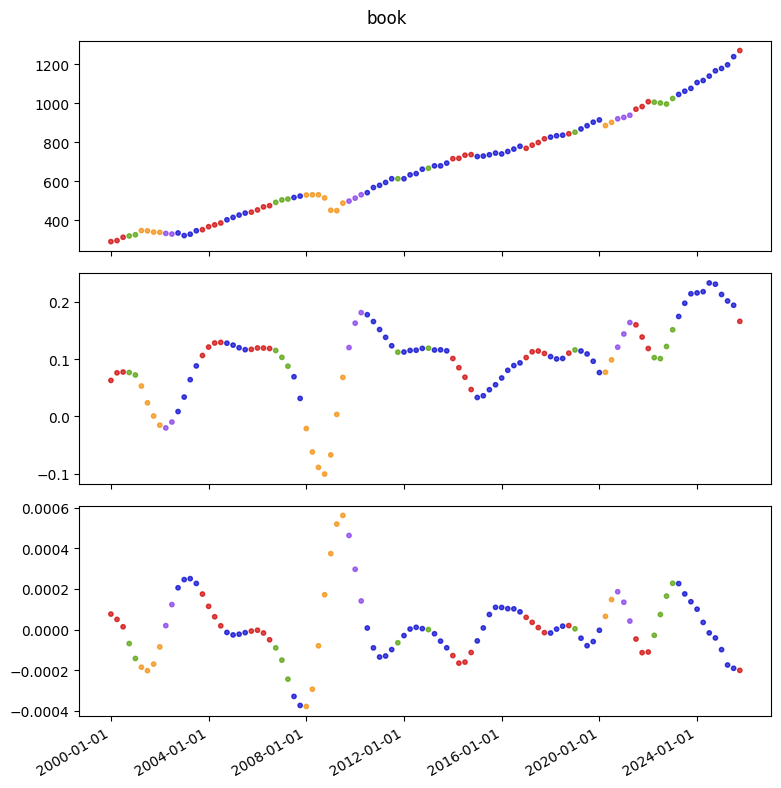

In [14]:
# fig, ax = plt.subplots(figsize=(8, 5))
# fig, ax = plt.subplots(figsize=(4, 3))

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

temp_df = quarterly_df[['book', 'market_code']].dropna()
date_strings = temp_df.index.values
dates = [datetime.strptime(str(d), '%Y-%m-%d').date() for d in date_strings]
values = temp_df['book'].values
regimes = temp_df['market_code'].values
smoothed_centered = temp_df['book'].rolling(window=5, min_periods=1, center=True).mean()
smoothed_dates_numeric = mdates.date2num(dates) - mdates.date2num(dates).min()
dy_dx = np.gradient(smoothed_centered, smoothed_dates_numeric)
derivative = pd.Series(dy_dx, index=dates)
derivative_smoothed = derivative.rolling(window=5, min_periods=1, center=True).mean()

second_der_smoothed = pd.Series(np.gradient(derivative_smoothed, smoothed_dates_numeric), index=dates).rolling(
    window=5, min_periods=1, center=True).mean()

# p = np.poly1d(coeffs)
# p = np.poly1d(deriv_coeffs)
# p = np.poly1d(deriv2_coeffs)
# y_smooth = p(smoothed_dates_numeric)



# plt.title('book')
# plt.grid(True)

fig.suptitle("book")

ax1.scatter(
    x=dates, y=values,
    c=regimes, cmap=my_cmap, # good maps include 'viridis' 'Set1' 'tab10' 'Accent' 'rainbow' 'turbo'
    s=10, # use 20 for a 8x5 plot, but 10 is better for smaller plots
    alpha=0.7,
    linestyle='solid', marker='o')
# plt.yscale('log')
formatter = mdates.DateFormatter('%Y-%m-%d')
ax1.xaxis.set_major_formatter(formatter)
fig.autofmt_xdate()

ax2.scatter(
    x=dates, y=derivative_smoothed,
    c=regimes, cmap=my_cmap,
    s=10,
    alpha=0.7,
    linestyle='solid', marker='o')

ax3.scatter(
    x=dates, y=second_der_smoothed,
    c=regimes, cmap=my_cmap,
    s=10,
    alpha=0.7,
    linestyle='solid', marker='o')

plt.tight_layout()
plt.show()


In [15]:
int(quarterly_df['book'].isna().sum())

199

book
min date = 1950-03-31
num nulls 199


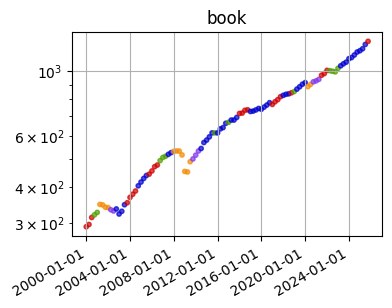

dividend
min date = 1950-03-31
num nulls 0


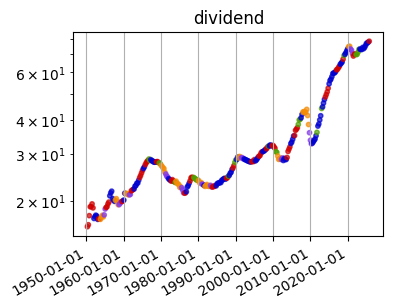

div_growth
min date = 1950-03-31
num nulls 159


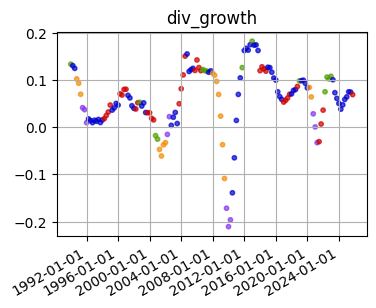

div_yield
min date = 1950-03-31
num nulls 0


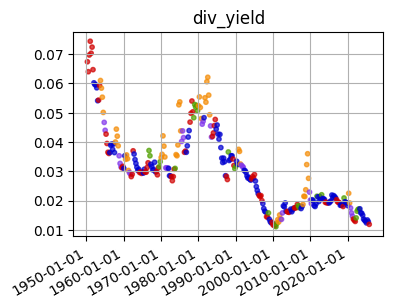

earn
min date = 1950-03-31
num nulls 0


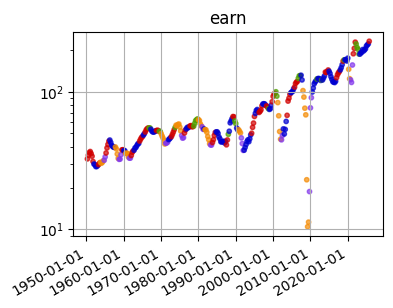

earn_yld
min date = 1950-03-31
num nulls 0


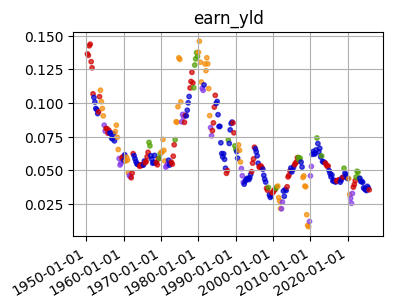

earn_growth
min date = 1950-03-31
num nulls 159


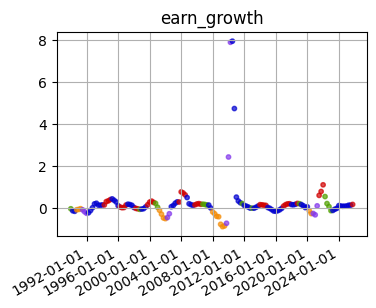

real_earn_growth
min date = 1950-03-31
num nulls 159


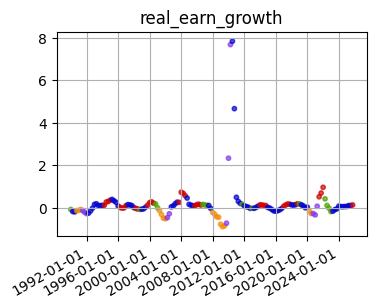

sp500_pe
min date = 1950-03-31
num nulls 0


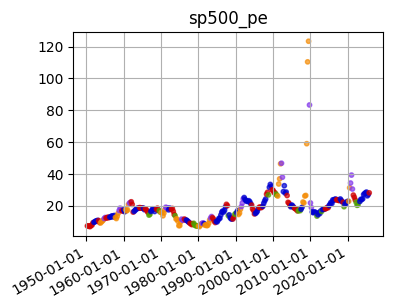

sp500
min date = 1950-03-31
num nulls 0


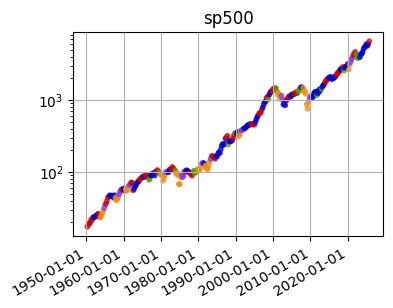

sp500_adj
min date = 1950-03-31
num nulls 0


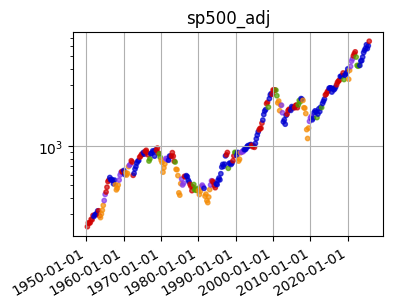

price_book
min date = 1950-03-31
num nulls 199


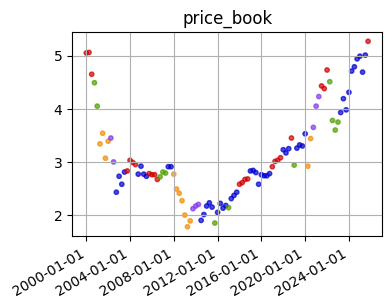

price_sales
min date = 1950-03-31
num nulls 203


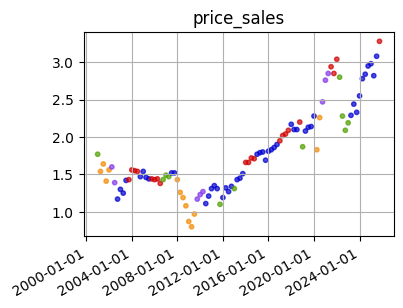

cape_shiller
min date = 1950-03-31
num nulls 0


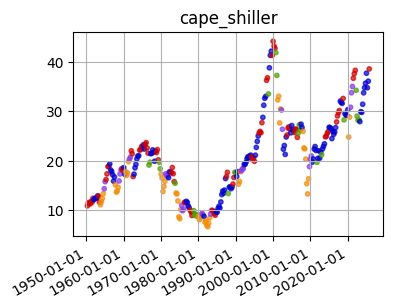

sales
min date = 1950-03-31
num nulls 203


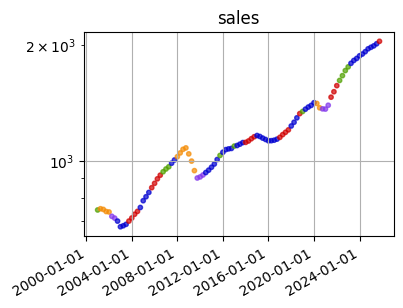

sales_growth
min date = 1950-03-31
num nulls 207


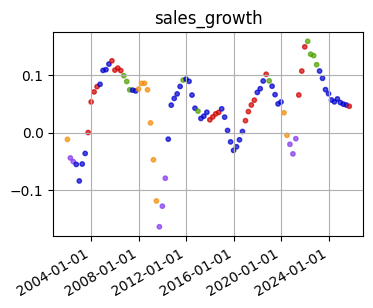

real_sales
min date = 1950-03-31
num nulls 203


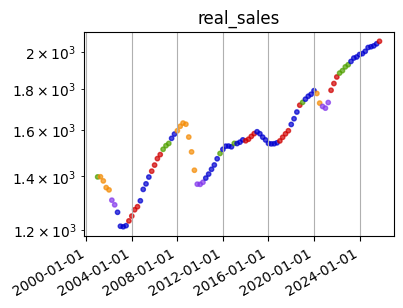

real_sales_growth
min date = 1950-03-31
num nulls 207


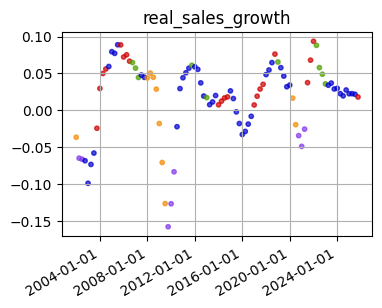

1mo_ustreas
min date = 1950-03-31
num nulls 206


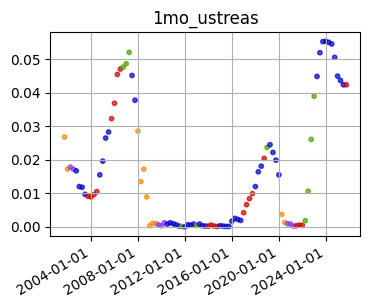

6mo_ustreas
min date = 1950-03-31
num nulls 160


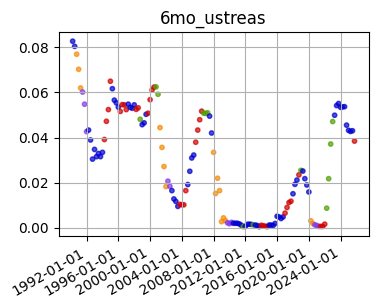

1yr_ustreas
min date = 1950-03-31
num nulls 160


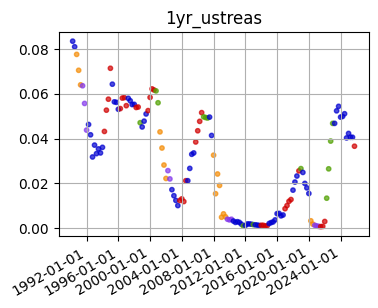

2yr_ustreas
min date = 1950-03-31
num nulls 160


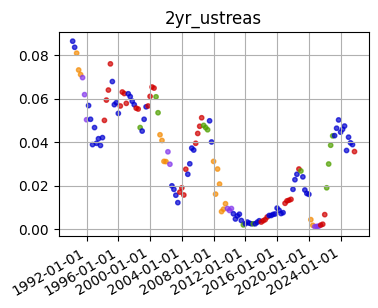

3yr_ustreas
min date = 1950-03-31
num nulls 160


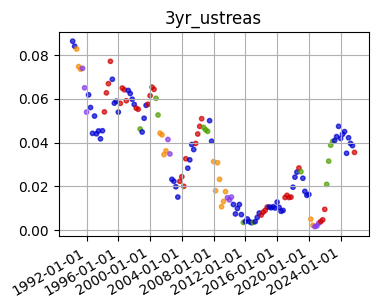

5yr_ustreas
min date = 1950-03-31
num nulls 160


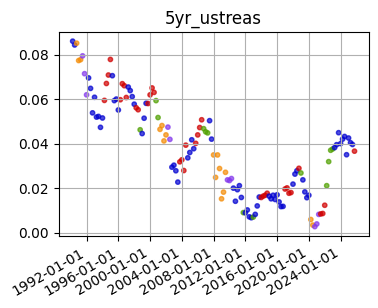

10yr_ustreas
min date = 1950-03-31
num nulls 0


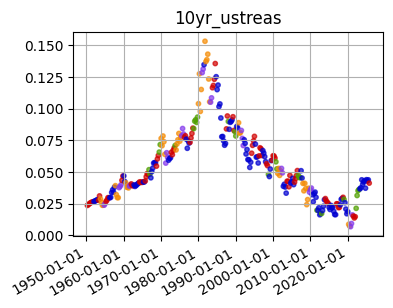

20yr_ustreas
min date = 1950-03-31
num nulls 175


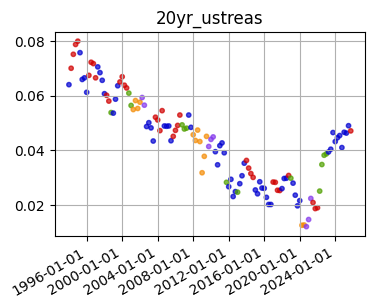

30yr_ustreas
min date = 1950-03-31
num nulls 175


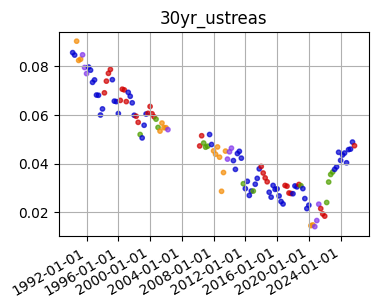

5yr_real_int
min date = 1950-03-31
num nulls 212


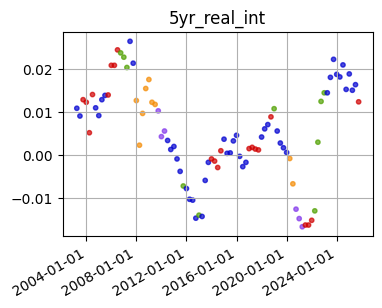

10yr_real_int
min date = 1950-03-31
num nulls 212


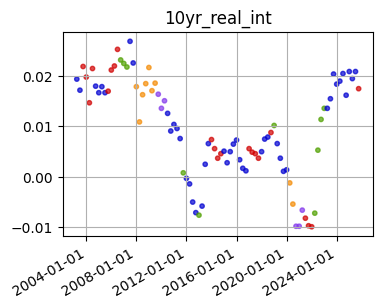

20yr_real_int
min date = 1950-03-31
num nulls 218


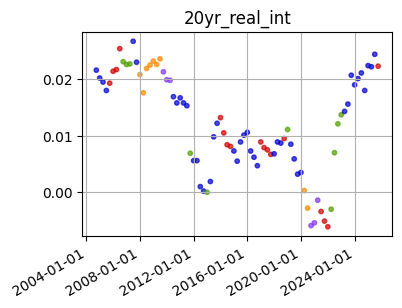

30yr_real_int
min date = 1950-03-31
num nulls 240


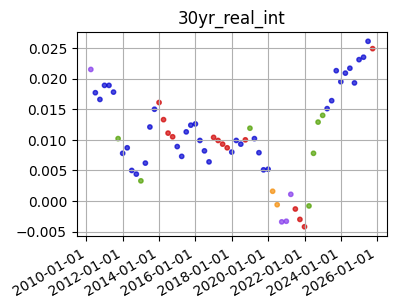

cpi
min date = 1950-03-31
num nulls 0


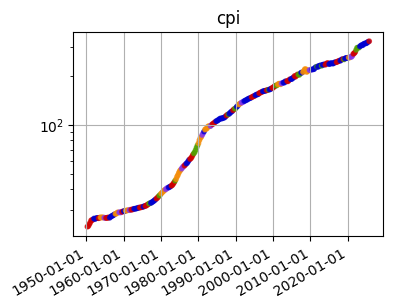

fed_debt
min date = 1950-03-31
num nulls 229


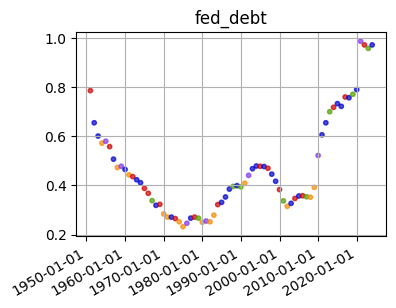

gdp
min date = 1950-03-31
num nulls 227


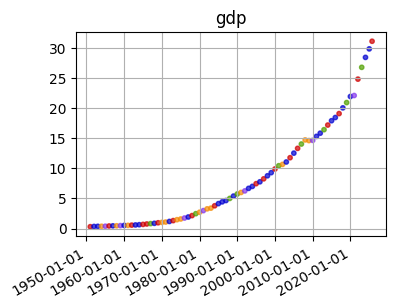

gdp_growth
min date = 1950-03-31
num nulls 0


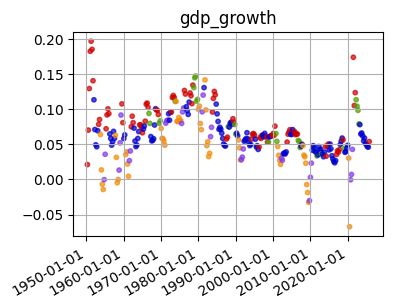

real_gdp
min date = 1950-03-31
num nulls 0


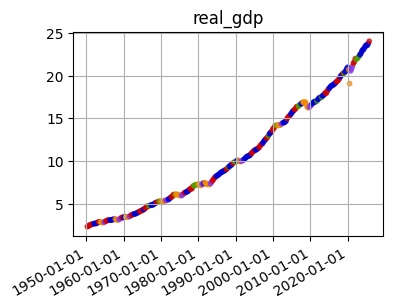

real_gdp_growth
min date = 1950-03-31
num nulls 0


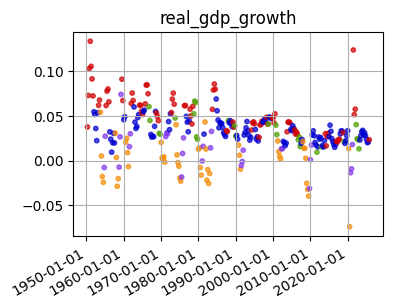

real_gdp_per_cap
min date = 1950-03-31
num nulls 0


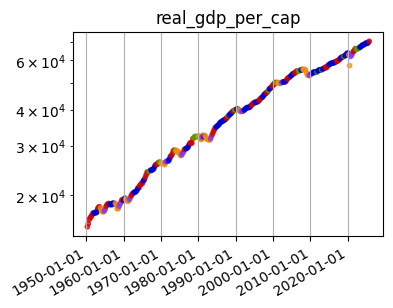

us_home_prices
min date = 1950-03-31
num nulls 40


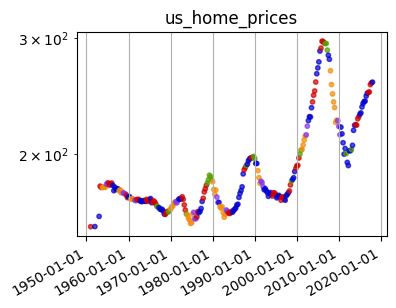

us_avg_income
min date = 1950-03-31
num nulls 254


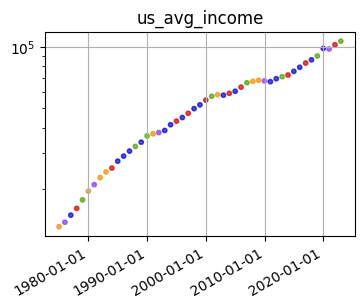

us_med_income
min date = 1950-03-31
num nulls 254


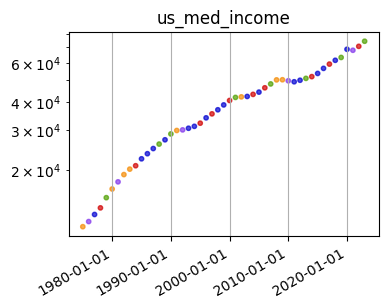

us_med_income_growth
min date = 1950-03-31
num nulls 255


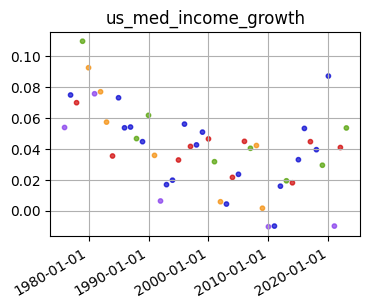

us_med_real_income
min date = 1950-03-31
num nulls 254


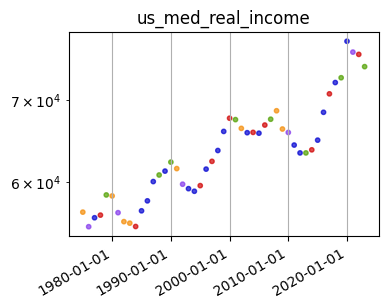

us_infl
min date = 1950-03-31
num nulls 0


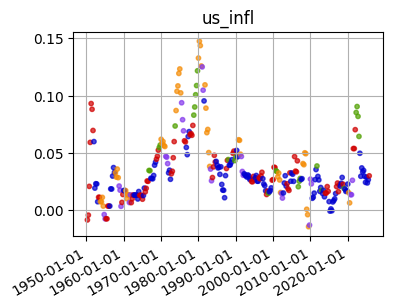

us_pop
min date = 1950-03-31
num nulls 121


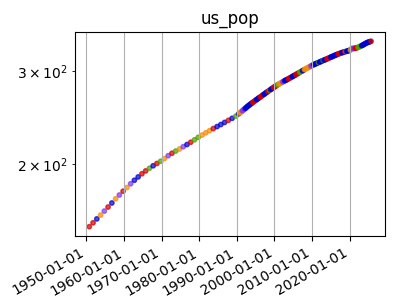

us_pop_growth
min date = 1950-03-31
num nulls 124


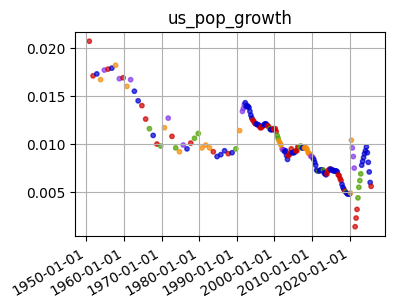

fred_gdp
min date = 1950-03-31
num nulls 0


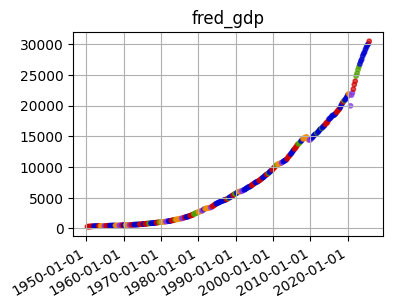

fred_gnp
min date = 1950-03-31
num nulls 0


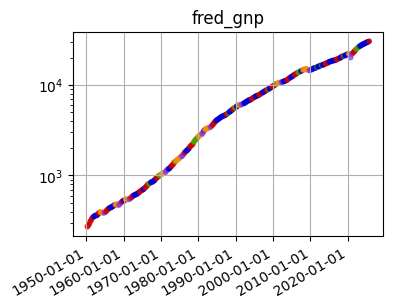

fred_baa
min date = 1950-03-31
num nulls 0


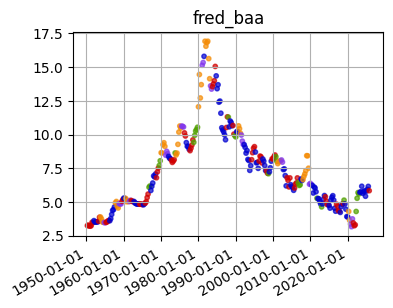

fred_aaa
min date = 1950-03-31
num nulls 0


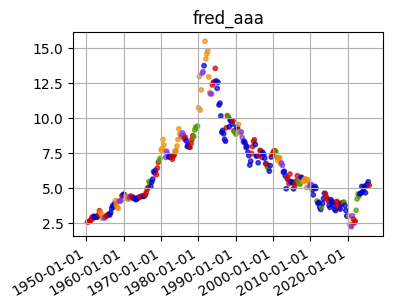

fred_cpi
min date = 1950-03-31
num nulls 0


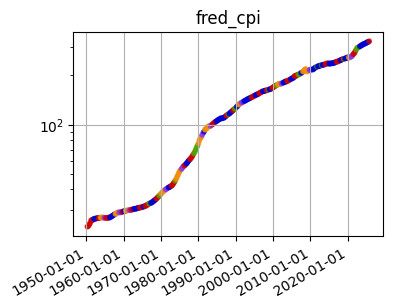

fred_gs10
min date = 1950-03-31
num nulls 13


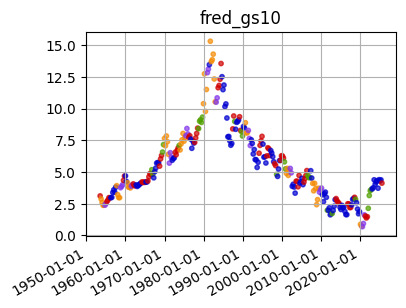

fred_tb3ms
min date = 1950-03-31
num nulls 0


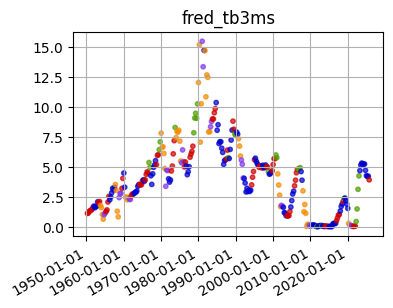

div_yield2
min date = 1950-03-31
num nulls 0


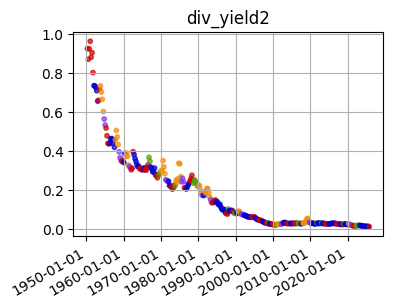

price_div
min date = 1950-03-31
num nulls 0


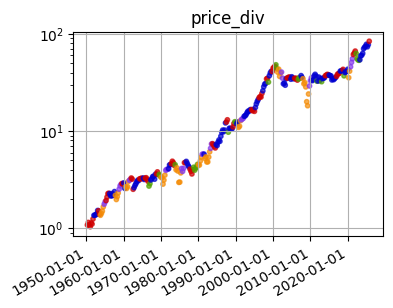

price_gdp
min date = 1950-03-31
num nulls 227


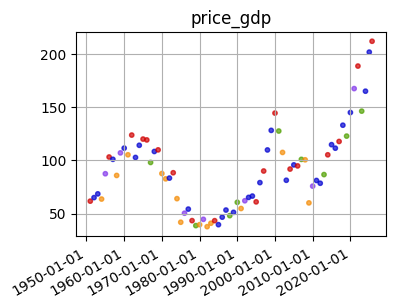

price_gdp2
min date = 1950-03-31
num nulls 0


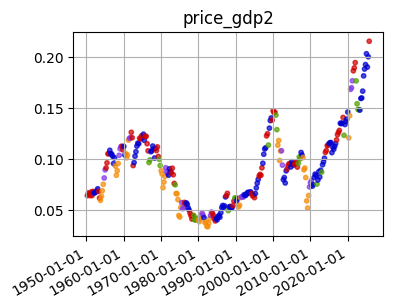

price_gnp2
min date = 1950-03-31
num nulls 0


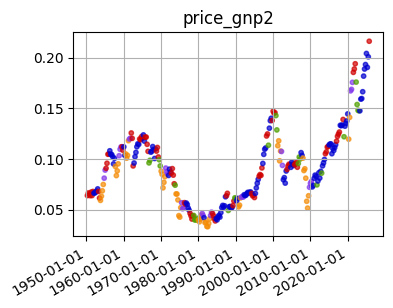

div_minus_baa
min date = 1950-03-31
num nulls 0


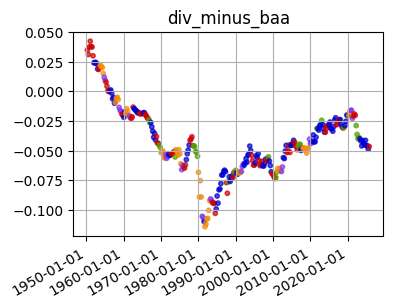

credit_spread
min date = 1950-03-31
num nulls 0


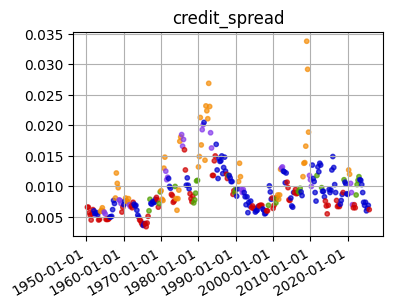

real_price2
min date = 1950-03-31
num nulls 0


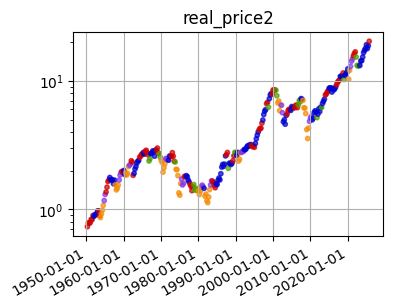

real_price3
min date = 1950-03-31
num nulls 0


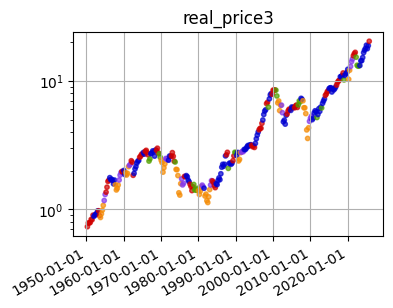

real_price_gdp2
min date = 1950-03-31
num nulls 227


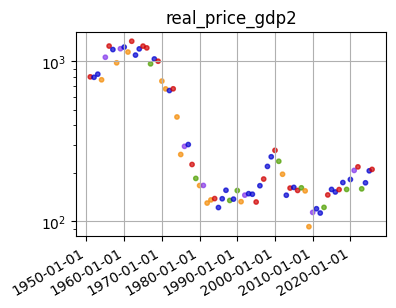

In [16]:
for col_name in quarterly_df.columns:
    if col_name == 'market_code':
        continue

    print(col_name)
        
    # fig, ax = plt.subplots(figsize=(8, 5))
    fig, ax = plt.subplots(figsize=(4, 3))
    date_strings = quarterly_df.index.values
    dates = [datetime.strptime(str(d), '%Y-%m-%d').date() for d in date_strings]
    values = quarterly_df[col_name].values
    regimes = quarterly_df['market_code'].values

    print("min date = " + str(dates[0]))
    print("num nulls " + str(int(quarterly_df[col_name].isna().sum())) )
    
    # plt.plot(dates, values, color='blue', linestyle='solid', marker='o') # Plot the data
    plt.scatter(
        x=dates, y=values,
        c=regimes, cmap=my_cmap, # good maps include 'viridis' 'Set1' 'tab10' 'Accent' 'rainbow' 'turbo'
        s=10, # use 20 for a 8x5 plot, but 10 is better for smaller plots
        alpha=0.7,
        linestyle='solid', marker='o')
    if col_name in ('book', 'dividend', 'earn', 'sp500', 'sp500_adj',
                    'sales', 'real_sales', 'cpi', 'real_gpd',
                    'real_gdp_per_cap', 'us_home_prices', 'us_avg_income',
                    'us_med_income', 'us_med_real_income', 'us_pop',
                    'fres_gdp', 'fred_gnp', 'fred_cpi', 'price_div',
                    'real_price2', 'real_price3', 'real_price_gdp2'):
        plt.yscale('log')
    formatter = mdates.DateFormatter('%Y-%m-%d')
    ax.xaxis.set_major_formatter(formatter)
    fig.autofmt_xdate()
    plt.title(col_name)
    plt.grid(True)
    plt.show()


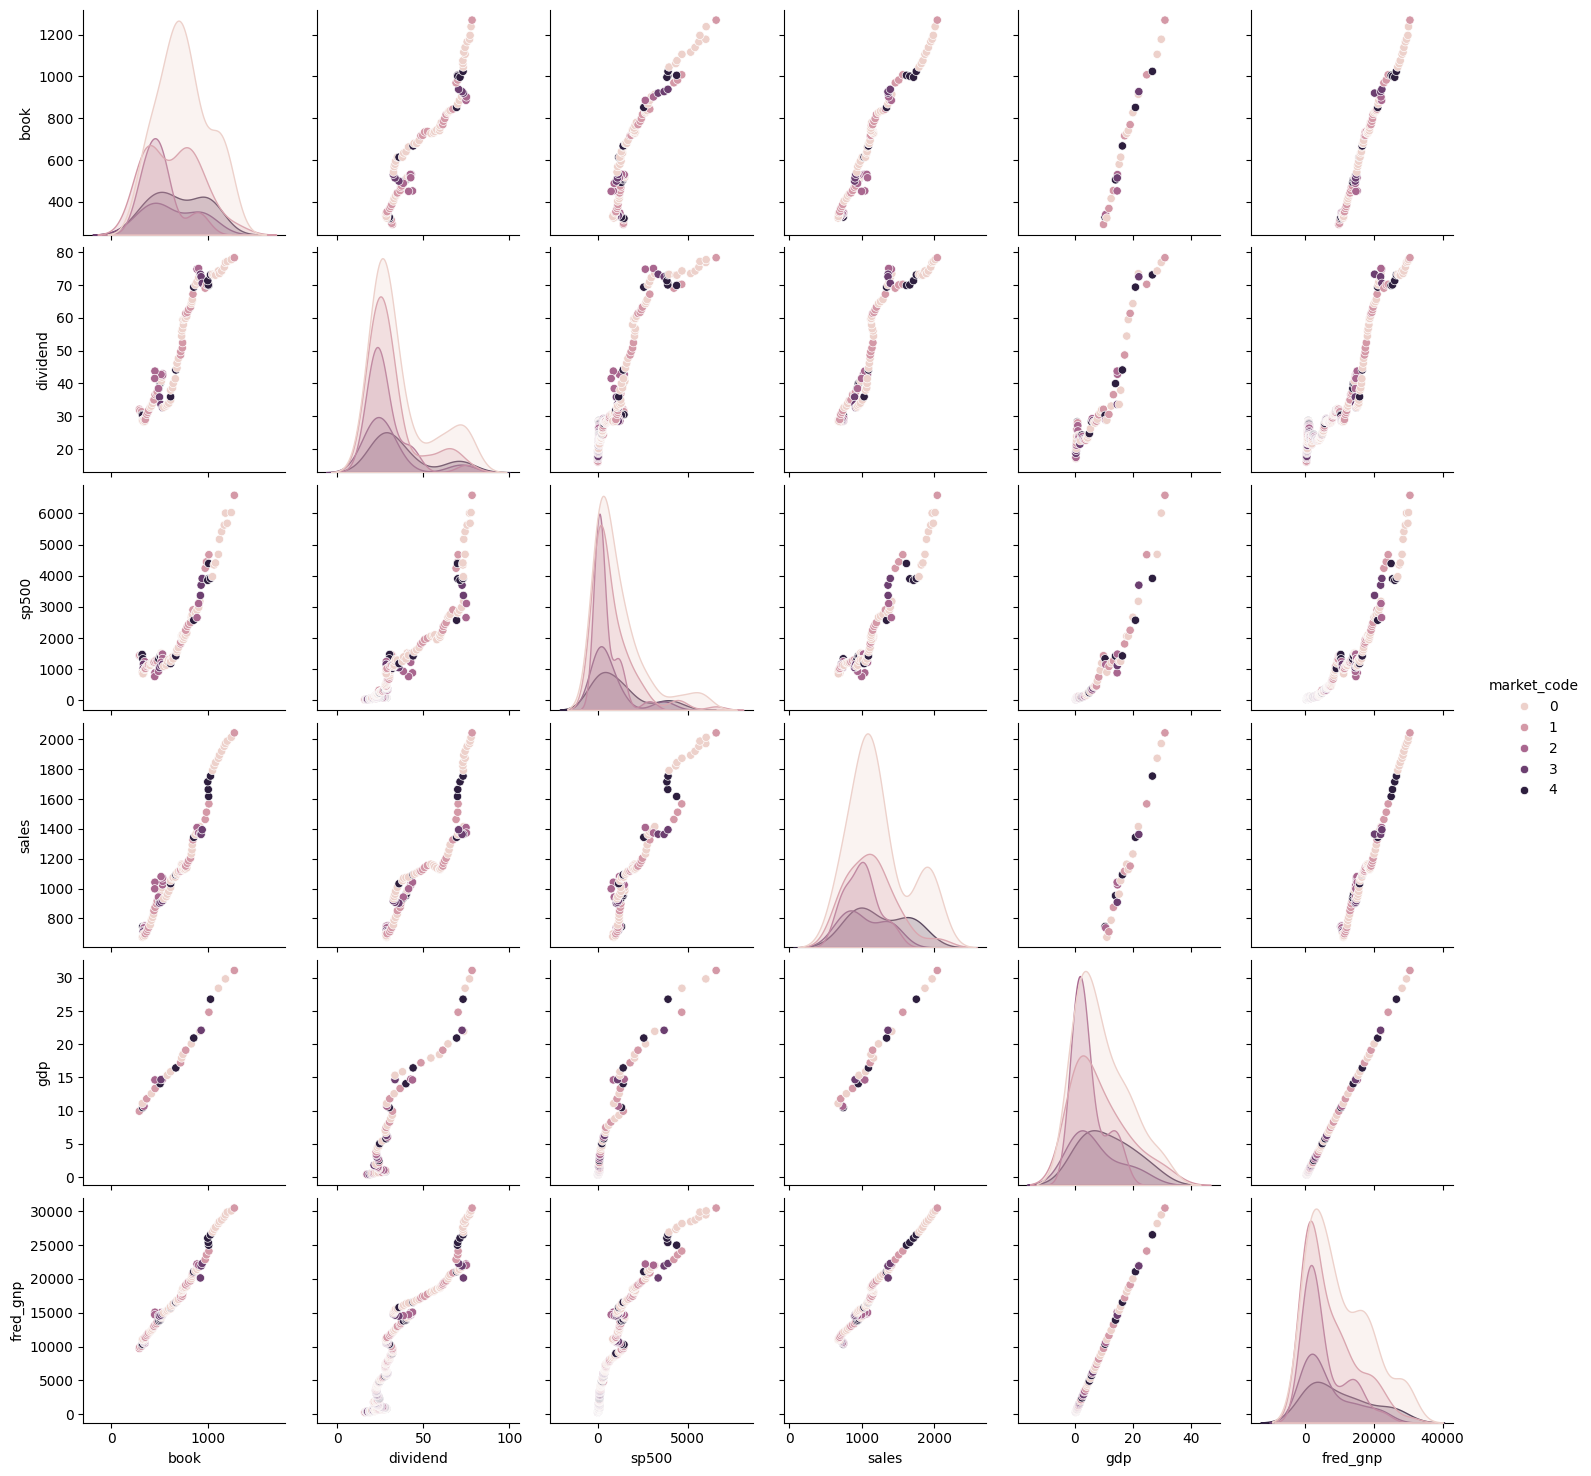

In [17]:
sns.pairplot(
    data = quarterly_df,
    vars = ['book','dividend','sp500','sales','gdp','fred_gnp'],
    hue  = "market_code",
    # optional but very useful tweaks:
    # diag_kind = "kde",      # or "hist", "auto"
    # kind      = "scatter",  # default anyway
    # palette   = "Set1",     # or "tab10", "husl", your custom list, etc.
    # height    = 2.5,        # size per panel — keep small if many variables
    # aspect    = 1.1,
    # corner    = True,       # triangular = less redundancy (often cleaner)
    # plot_kws  = {"s": 40, "alpha": 0.7, "edgecolor": "none"},
    #diag_kws  = {"alpha": 0.6}
);


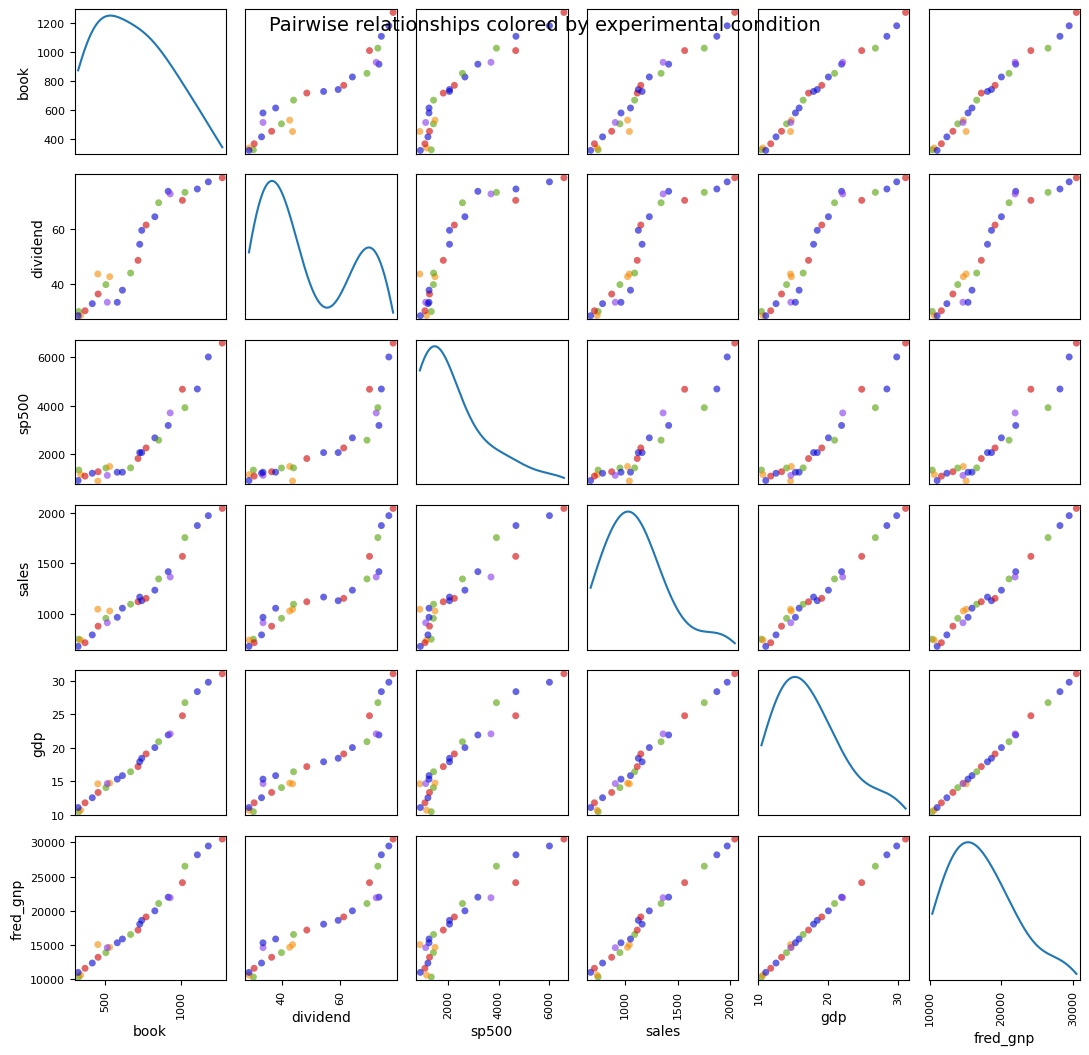

In [18]:
# colors = quarterly_df['market_code'].map(my_cmap)
temp_data = quarterly_df[['book','dividend','sp500','sales','gdp','fred_gnp', 'market_code']].dropna()
regimes = temp_data['market_code'].values

scatter_matrix(
    temp_data[['book','dividend','sp500','sales','gdp','fred_gnp']], #.select_dtypes(include='number'),
    figsize   = (11, 11),
    alpha     = 0.6,
    c         = regimes,
    cmap      = my_cmap,
    diagonal  = 'kde',
    marker    = 'o',
    s         = 25,                       # point size
    hist_kwds = {'bins': 20, 'alpha': 0.7},
    range_padding = 0.05
)

# Add a legend manually (scatter_matrix doesn't do it automatically)
# from matplotlib.lines import Line2D
# legend_elements = [
#     Line2D([0], [0], marker='o', color='w', label=label,
#            markerfacecolor=plt.cm.Set1(i/2), markersize=8)
#     for i, label in enumerate(['control', 'treatment_A', 'treatment_B'])
# ]

# plt.legend(handles=legend_elements, title='Condition', 
#            loc='upper right', bbox_to_anchor=(1.25, 1))

plt.suptitle("Pairwise relationships colored by experimental condition", 
             y=0.95, fontsize=14)
plt.tight_layout()
plt.show()


In [19]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [22]:
# original_rows = quarterly_df[vars_to_consider + ['market_code']].shape[0]
# current_df = quarterly_df[vars_to_consider + ['market_code']].copy()
# dropped_cols = []
# target_retention = 0.8  # e.g., retain at least 80% of rows; adjust as needed

# while current_df.dropna().shape[0] / original_rows < target_retention:
#     if current_df.shape[1] == 0:
#         break  # No columns left
    
#     results = {}
#     for col in current_df.columns:
#         temp_df = current_df.drop(columns=[col])
#         retained = temp_df.dropna().shape[0]
#         results[col] = retained
    
#     # Find the column that maximizes retained rows when dropped
#     best_col = max(results, key=results.get)
#     best_retained = results[best_col]
    
#     print(f"Dropping '{best_col}' would retain {best_retained} rows")
    
#     # Drop it and update
#     current_df = current_df.drop(columns=[best_col])
#     dropped_cols.append(best_col)
    
#     current_retained = current_df.dropna().shape[0]
#     print(f"After drop: Retained {current_retained}/{original_rows} rows")
    
#     if current_retained / original_rows >= target_retention:
#         break

# print(f"Dropped columns: {dropped_cols}")


In [23]:
# vars_to_consider = ['book','dividend','sp500','sales','gdp','fred_gnp']

# vars_to_consider = ['book', 'dividend', 'div_growth', 'div_yield', 'earn',
#                     'earn_yld',
#        'earn_growth', 'real_earn_growth', 'sp500_pe', 'sp500', 'sp500_adj',
#        'price_book', 'price_sales', 'cape_shiller', 'sales', 'sales_growth',
#        'real_sales', 'real_sales_growth', '1mo_ustreas', '6mo_ustreas',
#        '1yr_ustreas', '2yr_ustreas', '3yr_ustreas', '5yr_ustreas',
#        '10yr_ustreas', '20yr_ustreas', '30yr_ustreas', '5yr_real_int',
#        '10yr_real_int', '20yr_real_int', '30yr_real_int', 'cpi', 'fed_debt',
#        'gdp', 'gdp_growth', 'real_gdp', 'real_gdp_growth', 'real_gdp_per_cap',
#        'us_home_prices', 'us_avg_income', 'us_med_income',
#        'us_med_income_growth', 'us_med_real_income', 'us_infl', 'us_pop',
#        'us_pop_growth', 'fred_gdp', 'fred_gnp', 'fred_baa', 'fred_aaa',
#        'fred_cpi', 'fred_gs10', 'fred_tb3ms', 'div_yield2',
#        'price_div', 'price_gdp', 'price_gdp2', 'price_gnp2', 'div_minus_baa',
#        'credit_spread', 'real_price2', 'real_price3', 'real_price_gdp2']


# vars_to_consider = [
#     # 'book',
#     'dividend', 
#     # 'div_growth',
#     'div_yield',
#     'earn',
#     'earn_yld',
#     # 'earn_growth', 'real_earn_growth',
#     'sp500_pe', 'sp500', 'sp500_adj',
#     # 'price_book',
#     # 'price_sales',
#     'cape_shiller',
#     # 'sales',
#     # 'sales_growth',
#     #'real_sales', 'real_sales_growth', '1mo_ustreas', '6mo_ustreas',
#     # '1yr_ustreas', '2yr_ustreas', '3yr_ustreas', '5yr_ustreas',
#     '10yr_ustreas', '20yr_ustreas',
#     '30yr_ustreas', 
#     # '5yr_real_int',
#     # '10yr_real_int', '20yr_real_int',
#     # '30yr_real_int',
#     'cpi', 'fed_debt',
#     'gdp', 'gdp_growth', 'real_gdp', 'real_gdp_growth', 'real_gdp_per_cap',
#     # 'us_home_prices',
#     'us_avg_income', 'us_med_income',
#     'us_med_income_growth', 'us_med_real_income', 'us_infl', 'us_pop',
#     'us_pop_growth', 'fred_gdp', 'fred_gnp', 'fred_baa', 'fred_aaa',
#     'fred_cpi', 'fred_gs10', 'fred_tb3ms', 'div_yield2',
#     'price_div', 'price_gdp', 'price_gdp2', 'price_gnp2', 'div_minus_baa',
#     'credit_spread', 'real_price2', 'real_price3', 'real_price_gdp2']


vars_to_consider = [
    'dividend', 
    'div_yield',
    'earn',
    'earn_yld',
    'sp500_pe', 'sp500', 'sp500_adj',
    'cape_shiller',
    '10yr_ustreas',
    # '20yr_ustreas',
    # '30yr_ustreas', 
    'cpi',
    # 'fed_debt',
    # 'gdp',
    'gdp_growth', 'real_gdp', 'real_gdp_growth', 'real_gdp_per_cap',
    # 'us_avg_income',
    # 'us_med_income',
    # 'us_med_income_growth',
    # 'us_med_real_income',
    # 'us_infl',
    # 'us_pop',
    # 'us_pop_growth',
    'fred_gdp', 'fred_gnp', 'fred_baa', 'fred_aaa',
    'fred_cpi', 'fred_gs10', 'fred_tb3ms', 'div_yield2',
    'price_div',
    # 'price_gdp',
    'price_gdp2', 'price_gnp2', 'div_minus_baa',
    'credit_spread', 'real_price2', 'real_price3',
    # 'real_price_gdp2'
]



In [24]:
quarterly_df[vars_to_consider + ['market_code']]

,dividend,div_yield,earn,earn_yld,sp500_pe,sp500,sp500_adj,cape_shiller,10yr_ustreas,cpi,...,fred_tb3ms,div_yield2,price_div,price_gdp2,price_gnp2,div_minus_baa,credit_spread,real_price2,real_price3,market_code
1950-03-31,16.07,0.0674,32.54,0.1366,7.32,17.35,238.23,10.91,0.0236,23.60,...,1.12,0.926225,1.079652,0.064110,0.063843,0.0350,0.0066,0.735169,0.733926,1
1950-06-30,16.34,0.0640,34.58,0.1355,7.38,18.74,255.16,11.55,0.0242,23.80,...,1.15,0.871932,1.146879,0.066731,0.066441,0.0312,0.0066,0.787395,0.784757,1
1950-09-30,17.66,0.0697,36.12,0.1426,7.01,19.08,253.40,11.34,0.0249,24.40,...,1.30,0.925577,1.080408,0.065706,0.065410,0.0376,0.0057,0.781967,0.783895,1
1950-12-31,19.05,0.0744,36.81,0.1438,6.95,19.75,256.00,11.31,0.0255,25.00,...,1.34,0.964557,1.036745,0.064092,0.063759,0.0424,0.0053,0.790000,0.790633,1
1951-03-31,19.09,0.0703,35.55,0.1308,7.64,21.63,271.68,11.84,0.0259,25.80,...,1.40,0.882571,1.133054,0.067605,0.067267,0.0380,0.0045,0.838372,0.835781,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-30,75.44,0.0130,205.83,0.0356,28.09,5626.12,5782.31,35.70,0.0372,315.30,...,4.72,0.013409,74.577413,0.193025,0.193105,-0.0412,0.0074,17.843704,17.875907,0
2024-12-31,76.84,0.0124,215.80,0.0350,28.60,6010.91,6171.83,37.72,0.0439,315.61,...,4.27,0.012783,78.226314,0.203679,0.204040,-0.0456,0.0060,19.045372,18.925801,0
2025-03-31,77.16,0.0134,219.57,0.0381,26.23,5683.98,5759.61,34.79,0.0428,319.80,...,4.20,0.013575,73.664852,0.190577,0.190327,-0.0459,0.0064,17.773546,17.774380,0
2025-06-30,77.71,0.0128,223.56,0.0369,27.10,6029.95,6057.86,36.12,0.0438,322.56,...,4.23,0.012887,77.595548,0.200717,0.200703,-0.0487,0.0069,18.694041,18.759469,0


In [25]:
X = quarterly_df[vars_to_consider].dropna().values

In [26]:
len(X)

290

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
pca = PCA(n_components=5)
X_reduced = pca.fit_transform(X_scaled)
reduced_df = pd.DataFrame(X_reduced, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
print(pca.explained_variance_ratio_)

[0.58980964 0.19092431 0.08503794 0.05248979 0.03174997]


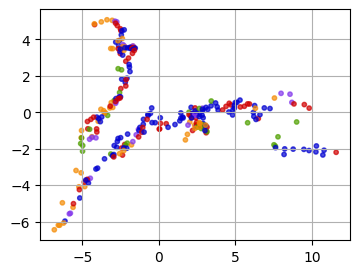

In [29]:
fig, ax = plt.subplots(figsize=(4, 3))

shorter_regimes = (quarterly_df[vars_to_consider + ['market_code']].dropna())['market_code'].values

plt.scatter(
    x=reduced_df['PC1'], y=reduced_df['PC2'],
    c=shorter_regimes, cmap=my_cmap,
    s=10,
    alpha=0.7,
    linestyle='solid', marker='o')
plt.grid(True)
plt.show()


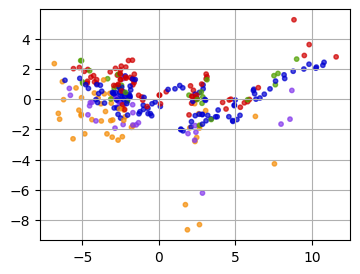

In [30]:
fig, ax = plt.subplots(figsize=(4, 3))

shorter_regimes = (quarterly_df[vars_to_consider + ['market_code']].dropna())['market_code'].values

plt.scatter(
    x=reduced_df['PC1'], y=reduced_df['PC3'],
    c=shorter_regimes, cmap=my_cmap,
    s=10,
    alpha=0.7,
    linestyle='solid', marker='o')
plt.grid(True)
plt.show()


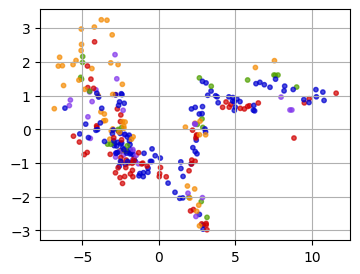

In [31]:
fig, ax = plt.subplots(figsize=(4, 3))

shorter_regimes = (quarterly_df[vars_to_consider + ['market_code']].dropna())['market_code'].values

plt.scatter(
    x=reduced_df['PC1'], y=reduced_df['PC4'],
    c=shorter_regimes, cmap=my_cmap,
    s=10,
    alpha=0.7,
    linestyle='solid', marker='o')
plt.grid(True)
plt.show()


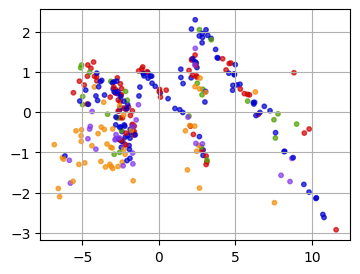

In [32]:
fig, ax = plt.subplots(figsize=(4, 3))

shorter_regimes = (quarterly_df[vars_to_consider + ['market_code']].dropna())['market_code'].values

plt.scatter(
    x=reduced_df['PC1'], y=reduced_df['PC5'],
    c=shorter_regimes, cmap=my_cmap,
    s=10,
    alpha=0.7,
    linestyle='solid', marker='o')
plt.grid(True)
plt.show()


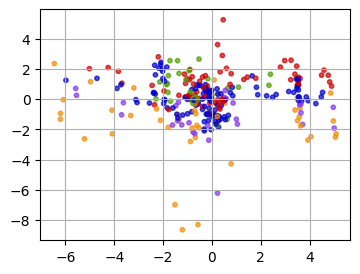

In [33]:
fig, ax = plt.subplots(figsize=(4, 3))

shorter_regimes = (quarterly_df[vars_to_consider + ['market_code']].dropna())['market_code'].values

plt.scatter(
    x=reduced_df['PC2'], y=reduced_df['PC3'],
    c=shorter_regimes, cmap=my_cmap,
    s=10,
    alpha=0.7,
    linestyle='solid', marker='o')
plt.grid(True)
plt.show()


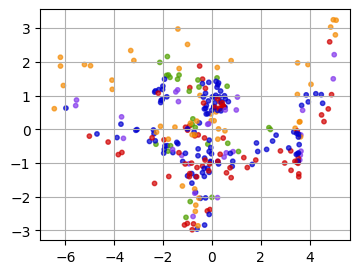

In [34]:
fig, ax = plt.subplots(figsize=(4, 3))

shorter_regimes = (quarterly_df[vars_to_consider + ['market_code']].dropna())['market_code'].values

plt.scatter(
    x=reduced_df['PC2'], y=reduced_df['PC4'],
    c=shorter_regimes, cmap=my_cmap,
    s=10,
    alpha=0.7,
    linestyle='solid', marker='o')
plt.grid(True)
plt.show()


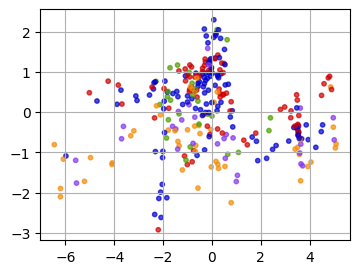

In [35]:
fig, ax = plt.subplots(figsize=(4, 3))

shorter_regimes = (quarterly_df[vars_to_consider + ['market_code']].dropna())['market_code'].values

plt.scatter(
    x=reduced_df['PC2'], y=reduced_df['PC5'],
    c=shorter_regimes, cmap=my_cmap,
    s=10,
    alpha=0.7,
    linestyle='solid', marker='o')
plt.grid(True)
plt.show()


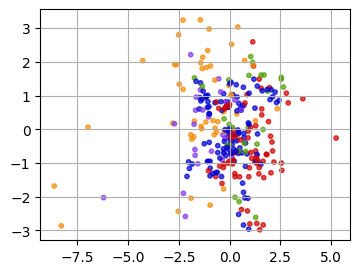

In [36]:
fig, ax = plt.subplots(figsize=(4, 3))

shorter_regimes = (quarterly_df[vars_to_consider + ['market_code']].dropna())['market_code'].values

plt.scatter(
    x=reduced_df['PC3'], y=reduced_df['PC4'],
    c=shorter_regimes, cmap=my_cmap,
    s=10,
    alpha=0.7,
    linestyle='solid', marker='o')
plt.grid(True)
plt.show()


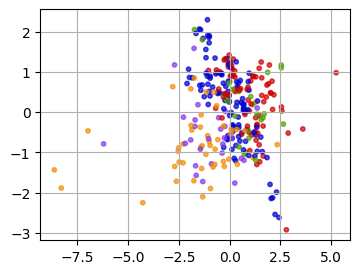

In [37]:
fig, ax = plt.subplots(figsize=(4, 3))

shorter_regimes = (quarterly_df[vars_to_consider + ['market_code']].dropna())['market_code'].values

plt.scatter(
    x=reduced_df['PC3'], y=reduced_df['PC5'],
    c=shorter_regimes, cmap=my_cmap,
    s=10,
    alpha=0.7,
    linestyle='solid', marker='o')
plt.grid(True)
plt.show()


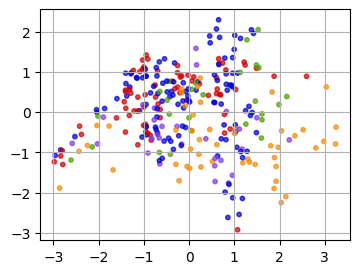

In [38]:
fig, ax = plt.subplots(figsize=(4, 3))

shorter_regimes = (quarterly_df[vars_to_consider + ['market_code']].dropna())['market_code'].values

plt.scatter(
    x=reduced_df['PC4'], y=reduced_df['PC5'],
    c=shorter_regimes, cmap=my_cmap,
    s=10,
    alpha=0.7,
    linestyle='solid', marker='o')
plt.grid(True)
plt.show()
